In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from ta.momentum import rsi
from ta.trend import macd, macd_signal
from ta.volatility import average_true_range
from ta.utils import dropna
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [3]:
SYMBOL = "^NSEBANK"  
START_DATE = "2008-01-01"
END_DATE = "2024-01-03"
SEQ_LEN = 60                 
TEST_SIZE = 0.2               
VAL_SIZE = 0.1        
BATCH = 32
EPOCHS = 100
MODEL_PATH = "best_lstm_multi_feature.h5"

In [4]:
print("Downloading data...")
df = yf.download(SYMBOL, start=START_DATE, end=END_DATE)
if df.empty:
    raise RuntimeError("No data downloaded - check symbol or dates.")

df = df[['Open','High','Low','Close','Volume']].copy()

print("Computing indicators...")
high_s = pd.Series(df['High'].values.squeeze(), index=df.index)
low_s  = pd.Series(df['Low'].values.squeeze(), index=df.index)
close_s = pd.Series(df['Close'].values.squeeze(), index=df.index)

high_s = pd.to_numeric(high_s, errors='coerce')
low_s  = pd.to_numeric(low_s,  errors='coerce')
close_s = pd.to_numeric(close_s, errors='coerce')

df['RSI'] = rsi(close=close_s, window=14)
df['MACD'] = macd(close=close_s, window_slow=26, window_fast=12)
df['MACD_signal'] = macd_signal(close=close_s, window_slow=26, window_fast=12)
df['ATR'] = average_true_range(high=high_s, low=low_s, close=close_s, window=14)

# EMAs and derived features (these operate on df['Close'] which should be fine now)
df['EMA_12'] = close_s.ewm(span=12, adjust=False).mean()
df['EMA_26'] = close_s.ewm(span=26, adjust=False).mean()
df['EMA_diff'] = df['EMA_12'] - df['EMA_26']
df['HL_PCT'] = (high_s - low_s) / close_s
df['PCT_change'] = close_s.pct_change()
df['momentum_1'] = close_s - close_s.shift(1)
df['momentum_5'] = close_s - close_s.shift(5)
df['target_return'] = np.log(df['Close'].shift(-1) / df['Close'])

print("Done...")


[*********************100%***********************]  1 of 1 completed

Computing indicators...
Done...


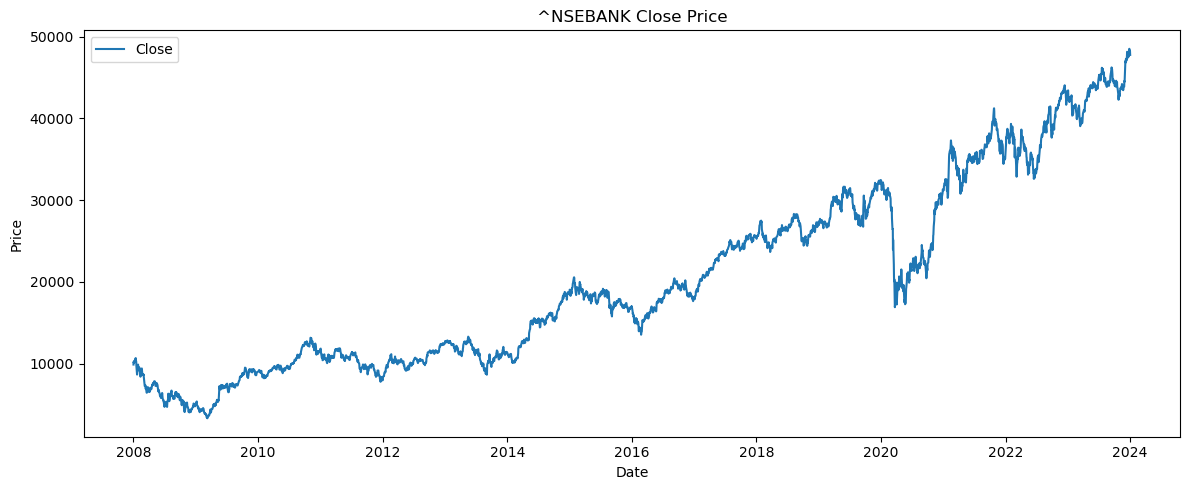

In [5]:
# Price history
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], label='Close')
plt.title(f'{SYMBOL} Close Price')
plt.xlabel('Date'); plt.ylabel('Price'); plt.legend()
plt.tight_layout()
plt.savefig("banknifty_price.png", dpi = 600)
plt.show()


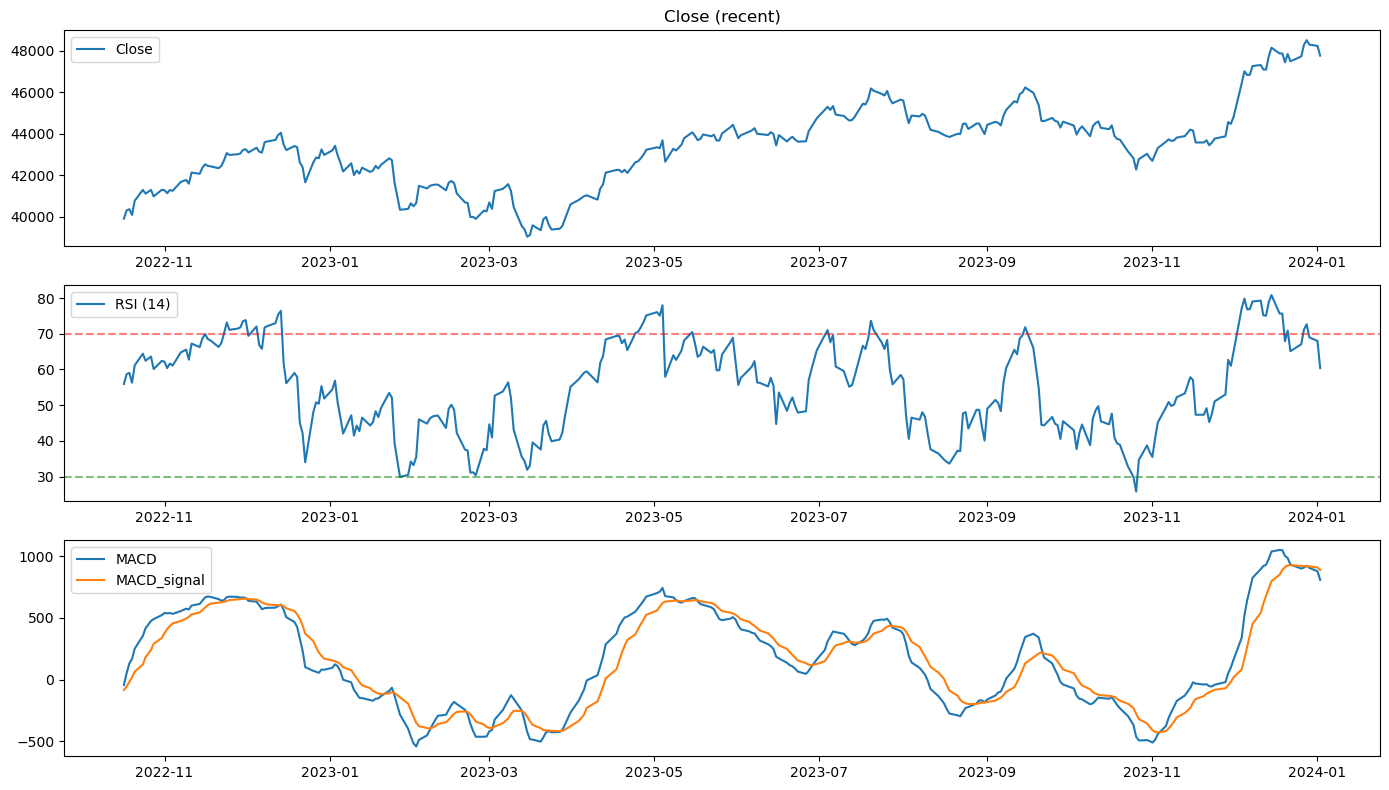

In [6]:
# Indicators over a recent window for visual check
window = 300
if len(df) > window:
    vis_df = df[-window:]
else:
    vis_df = df.copy()

plt.figure(figsize=(14,8))
plt.subplot(3,1,1)
plt.plot(vis_df.index, vis_df['Close'], label='Close')
plt.title('Close (recent)')
plt.legend()

plt.subplot(3,1,2)
plt.plot(vis_df.index, vis_df['RSI'], label='RSI (14)')
plt.axhline(70, color='red', linestyle='--', alpha=0.5)
plt.axhline(30, color='green', linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(3,1,3)
plt.plot(vis_df.index, vis_df['MACD'], label='MACD')
plt.plot(vis_df.index, vis_df['MACD_signal'], label='MACD_signal')
plt.legend()

plt.tight_layout()
plt.savefig("rsi_macd.png", dpi = 600)
plt.show()

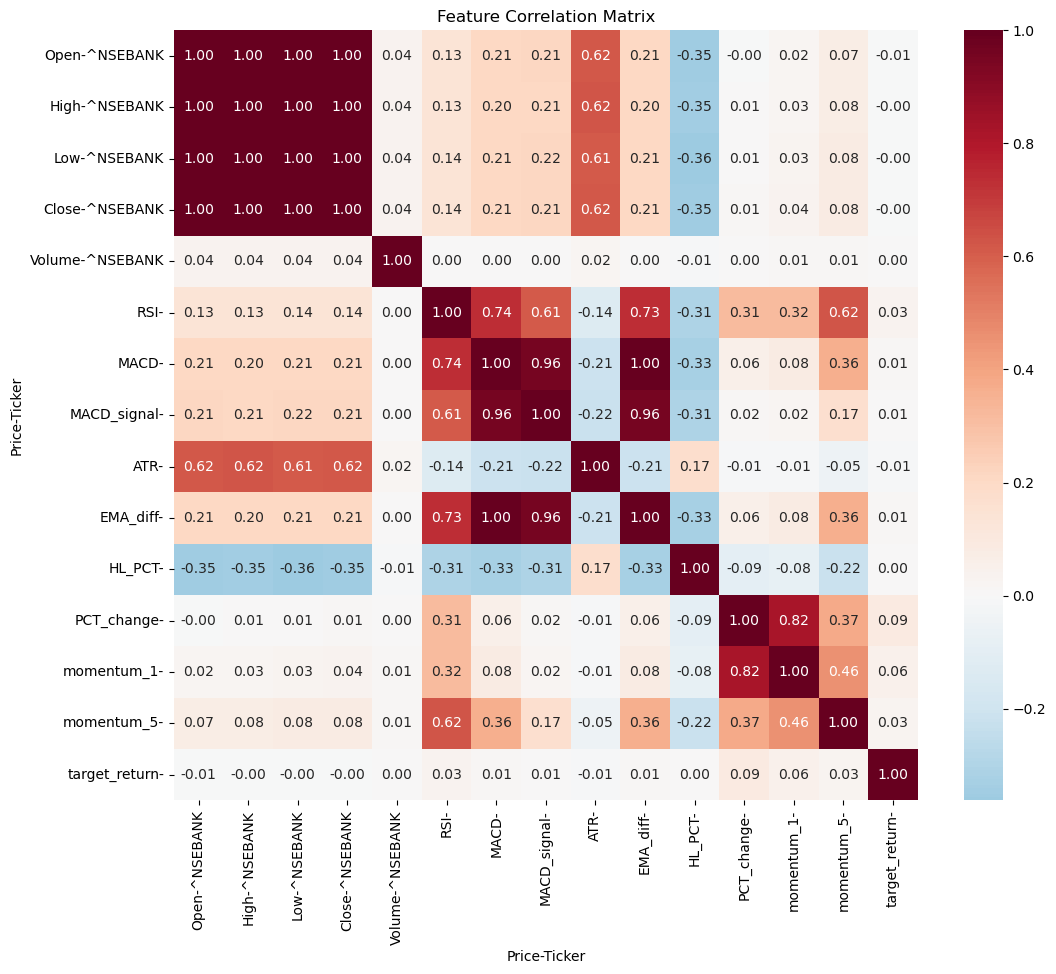

In [7]:
feature_cols = ['Open','High','Low','Close','Volume','RSI','MACD','MACD_signal','ATR',
                'EMA_diff','HL_PCT','PCT_change','momentum_1','momentum_5', 'target_return']

corr = df[feature_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.savefig("feature_correlation.png", dpi = 600)
plt.show()

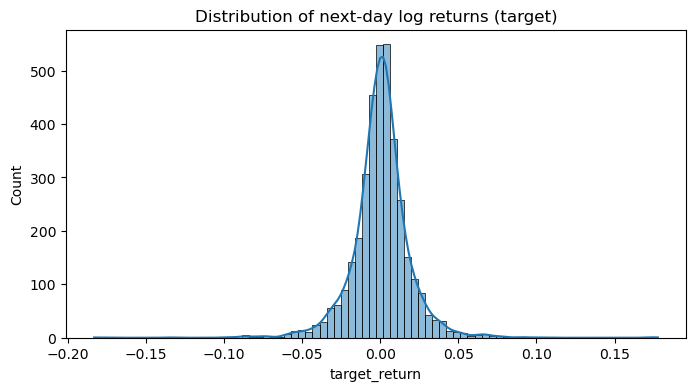

In [47]:
plt.figure(figsize=(8,4))
sns.histplot(df['target_return'], bins=80, kde=True)
plt.title('Distribution of next-day log returns (target)')
plt.show()

In [8]:
n = len(df)
test_n = int(np.floor(TEST_SIZE * n))
trainval_n = n - test_n
val_n = int(np.floor(VAL_SIZE * trainval_n))
train_n = trainval_n - val_n

train_df = df.iloc[:train_n]
val_df   = df.iloc[train_n:train_n+val_n]
test_df  = df.iloc[train_n+val_n:]

print(f"Data sizes -> total: {n}, train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

Data sizes -> total: 3938, train: 2836, val: 315, test: 787


In [9]:
FEATURES = ['Open','High','Low','Close','Volume','RSI','MACD','MACD_signal','ATR',
            'EMA_diff','HL_PCT','PCT_change','momentum_1','momentum_5']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[FEATURES])
X_val   = scaler_X.transform(val_df[FEATURES])
X_test  = scaler_X.transform(test_df[FEATURES])

y_train = train_df['target_return'].values.reshape(-1,1)
y_val   = val_df['target_return'].values.reshape(-1,1)
y_test  = test_df['target_return'].values.reshape(-1,1)

scaler_y.fit(y_train)   # fit only on train target
y_train_s = scaler_y.transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

In [10]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr, y_tr = create_sequences(X_train, y_train_s, SEQ_LEN)

X_for_val = np.vstack([X_train[-SEQ_LEN:], X_val])
y_for_val = np.vstack([y_train_s[-SEQ_LEN:], y_val_s])
X_v, y_v = create_sequences(X_for_val, y_for_val, SEQ_LEN)

X_for_test = np.vstack([X_val[-SEQ_LEN:], X_test])
y_for_test = np.vstack([y_val_s[-SEQ_LEN:], y_test_s])
X_t, y_t = create_sequences(X_for_test, y_for_test, SEQ_LEN)

print("Sequence shapes ->", X_tr.shape, y_tr.shape, X_v.shape, y_v.shape, X_t.shape, y_t.shape)


Sequence shapes -> (2776, 60, 14) (2776, 1) (315, 60, 14) (315, 1) (787, 60, 14) (787, 1)


In [11]:
tf.keras.backend.clear_session()
model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, X_tr.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_loss', verbose=1)
]

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          73,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 124,993 (488.25 KB)

 Trainable params: 124,865 (487.75 KB)

 Non-trainable params: 128 (512.00 B)

None


In [12]:
history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                    epochs=EPOCHS, batch_size=BATCH, callbacks=callbacks, verbose=2)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.13055, saving model to best_lstm_multi_feature.h5


87/87 - 6s - 65ms/step - loss: 0.1860 - val_loss: 0.1306 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_loss improved from 0.13055 to 0.08231, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 33ms/step - loss: 0.1042 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_loss improved from 0.08231 to 0.05050, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 34ms/step - loss: 0.0639 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_loss improved from 0.05050 to 0.03045, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 33ms/step - loss: 0.0377 - val_loss: 0.0305 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: val_loss improved from 0.03045 to 0.01870, saving model to best_lstm_multi_feature.h5


...

87/87 - 3s - 33ms/step - loss: 0.0051 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 9/100

Epoch 9: val_loss improved from 0.00767 to 0.00710, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 33ms/step - loss: 0.0040 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 10/100

Epoch 10: val_loss improved from 0.00710 to 0.00689, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 33ms/step - loss: 0.0036 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 11/100

Epoch 11: val_loss improved from 0.00689 to 0.00683, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 35ms/step - loss: 0.0034 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 12/100

Epoch 12: val_loss improved from 0.00683 to 0.00683, saving model to best_lstm_multi_feature.h5


87/87 - 3s - 35ms/step - loss: 0.0033 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 13/100

Epoch 13: val_loss did not improve from 0.00683
87/87 - 3s - 33ms/step - loss: 0.0033 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 14/100

Epoch 14: val_loss did not improve from 0.00683
87/87 - 3s - 33ms/step - loss: 0.0033 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 15/100

Epoch 15: val_loss did not improve from 0.00683
87/87 - 3s - 33ms/step - loss: 0.0033 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 16/100

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: val_loss did not improve from 0.00683
87/87 - 3s - 33ms/step - loss: 0.0033 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 17/100

Epoch 17: val_loss did not improve from 0.00683
87/87 - 3s - 33ms/step - loss: 0.0033 - val_loss: 0.0068 - learning_rate: 5.0000e-04
Epoch 18/100

Epoch 18: val_loss did not improve from 0.00683
87/87 - 3s - 33ms/step - loss: 0.0033 - val_loss: 0.0068 - l

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
pred_test shape: (787,)
test_close shape: (787,)
pred_prices shape: (786,)


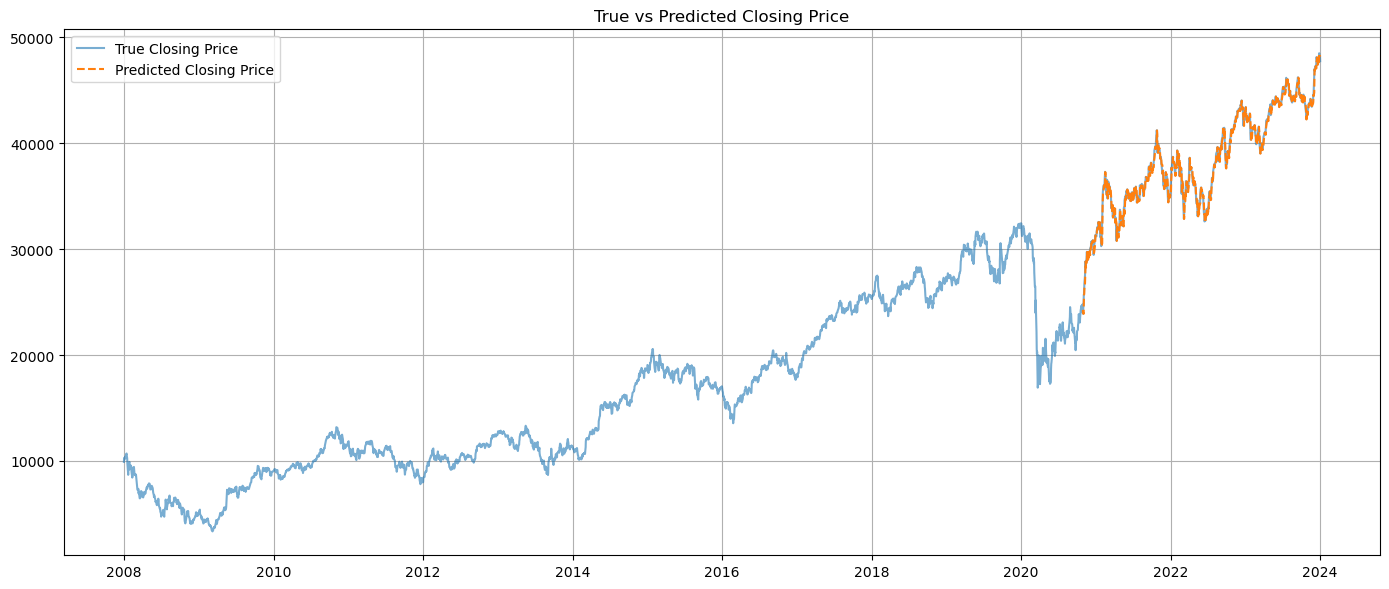


 Validation
RMSE: 0.025390376532160457
Directional Accuracy: 0.4793650793650794

 Test
RMSE: 0.012646841058889274
Directional Accuracy: 0.4618320610687023


In [31]:
# predictions
pred_val = model.predict(X_v)
pred_test = model.predict(X_t)

# inverse scaling
pred_val = scaler_y.inverse_transform(pred_val)
pred_test = scaler_y.inverse_transform(pred_test)

y_val_true = scaler_y.inverse_transform(y_v)
y_test_true = scaler_y.inverse_transform(y_t)

# FORCE 1D arrays
pred_val = pred_val.flatten()
pred_test = pred_test.flatten()

y_val_true = y_val_true.flatten()
y_test_true = y_test_true.flatten()

# =========================
# RMSE helper
# =========================

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))


# =========================
# PRICE RECONSTRUCTION
# =========================

# ensure 1D arrays
pred_test = np.asarray(pred_test).reshape(-1)
test_close = np.asarray(test_df['Close']).reshape(-1)

print("pred_test shape:", pred_test.shape)
print("test_close shape:", test_close.shape)

# predicted price(t+1) = price(t) * exp(return)
pred_prices = test_close[:-1] * np.exp(pred_test[:-1])

print("pred_prices shape:", pred_prices.shape)

# create series aligned with test index
pred_price_series = pd.Series(
    data=pred_prices.flatten(),
    index=test_df.index[1:1+len(pred_prices)]
)
# =========================
# PLOT
# =========================

plt.figure(figsize=(14,6))

plt.plot(df['Close'], label="True Closing Price", alpha=0.6)
plt.plot(pred_price_series, label="Predicted Closing Price", linestyle="--")

plt.title("True vs Predicted Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_prediction.png", dpi = 600)
plt.show()


# =========================
# EVALUATION
# =========================

def mask_and_eval(y_true, y_pred, name="set"):

    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)

    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

    y_true_m = y_true[mask]
    y_pred_m = y_pred[mask]

    print("\n", name)
    print("RMSE:", rmse(y_true_m, y_pred_m))
    print("Directional Accuracy:", np.mean(np.sign(y_true_m) == np.sign(y_pred_m)))

    return y_true_m, y_pred_m


y_val_m, pred_val_m = mask_and_eval(y_val_true, pred_val, "Validation")
y_test_m, pred_test_m = mask_and_eval(y_test_true, pred_test, "Test")

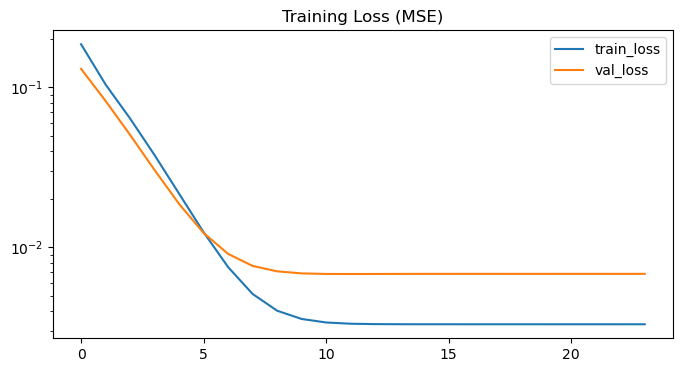

In [32]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.yscale('log')
plt.legend(); plt.title('Training Loss (MSE)')
plt.savefig("lstm_training_loss.png", dpi = 300)
plt.show()